In [63]:
!pip install -q "numpy<2" "scipy<1.16" pmdarima sktime

⚠️ **NOTE: After the restart, you don't need to rerun Cell 1 !!!. Jump to the next cell: Time Series - First Lecture**

# Time Series - First Lecture




In [1]:
# Setting notebook to ignore some warnings!
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and cleaning the timeseries data

In [3]:
# Source: https://www.kaggle.com/code/milanpatra/us-birthsdata-analysis/data
url = "https://wagon-public-datasets.s3.amazonaws.com/data-analytics/machine-learning/births.csv"
births = pd.read_csv(url)

# We have data from 1969 - 1988. For the first part of this lecture, we will limit the data to the 1970-1974 period.
births = births[births['year'].isin([1970, 1971, 1972, 1973, 1974])]

### Inspecting the Dataset:

In [ ]:
births.head()

,year,month,day,gender,births
768,1970,1,1.0,F,4064
769,1970,1,1.0,M,4308
770,1970,1,2.0,F,4536
771,1970,1,2.0,M,4698
772,1970,1,3.0,F,4398


In [4]:
births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3825 entries, 768 to 4592
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    3825 non-null   int64  
 1   month   3825 non-null   int64  
 2   day     3825 non-null   float64
 3   gender  3825 non-null   object 
 4   births  3825 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 179.3+ KB


In [5]:
# The day column is a Float type when it should be an Integer. We can change the float type to int.
births.day = births.day.astype(int)

In [6]:
# Finding nulls (in %/rate):
births.isnull().mean()

,0
year,0.0
month,0.0
day,0.0
gender,0.0
births,0.0


### Building our datetime index

In [7]:
# Create a datetime from the year, month, day
# In the data, every month has 31 days, with the value for day 31 = day 30
# So use errors='coerce', this will give NAs for those non-existent dates

births['date'] = pd.to_datetime(births[['year', 'month', 'day']], errors='coerce')      # Creating datetime from year, month, day.
births = births.dropna()                                                                # Dropping rows with Nulls (from the coerce).
births = births.set_index('date')                                                       # Setting date as the index.

### Resampling our daily data --> monthly data

In [8]:
# Inspecting our clean dataset:
births.head()

,year,month,day,gender,births
date,,,,,
1970-01-01,1970,1,1,F,4064
1970-01-01,1970,1,1,M,4308
1970-01-02,1970,1,2,F,4536
1970-01-02,1970,1,2,M,4698
1970-01-03,1970,1,3,F,4398


In [9]:
# At this point we have our daily data with two entries per day: F and M.
# We want to do a monthly analysis for births in general! --> resample("M")
# When resampling to months, all the other columns are obsolete as we are doing an aggregation (year,month,day,gender)
births_month = births['births'].resample('M').sum()
births_month.head()

# births.resample("M").sum()                                  # Uncomment to show why they are obsolete!


,births
date,
1970-01-31,302140
1970-02-28,281182
1970-03-31,307208
1970-04-30,286924
1970-05-31,297996


### Plotting our clean dataset:

In [10]:
## Plotting our clean dataset

# Setting up the base plot configuration
# Shared across all graphs
import plotly.express as px
import plotly.graph_objects as go

title_config = dict(
    text='Monthly births in the USA',
    x=0.5,
    y=0.9,
    xanchor='center',
    yanchor='bottom'
)

legend_config = dict(
    xanchor='left',
    yanchor='top',
    x=.8,
    y=.92,
    traceorder="normal",
    font=dict(
        family="sans-serif",
        size=12,
        color="black"
    ),
    bgcolor='rgba(0,0,0,0)'
)

layout_config = dict(
    autosize=False, width=800, height=800,
    title=title_config,
    xaxis_title='Month',
    yaxis_title='Births',
    showlegend=True,
    legend=legend_config,
    yaxis_range=[220_000,340_000]
)

layout_config_2 = dict(
    title=title_config,
    xaxis_title='Month',
    yaxis_title='Births',
    showlegend=True,
    yaxis_range=[220_000,340_000]
)

In [11]:
# All data
fig = go.Figure()
fig.add_trace(go.Scatter(x=births_month.index,
                         y=births_month.values ,
                         line=dict(color="royalblue", width=3),
                         name="Births"
                         ))
fig.update_layout(**layout_config)

## Splitting our data (Train-Test split)

In [12]:
from sktime.forecasting.model_selection import temporal_train_test_split

df_train, df_test = temporal_train_test_split(births_month, test_size = 24)     #Last 2 years of data as our testing set

In [13]:
# Inspecting the split
df_train.shape, df_test.shape

((36,), (24,))

In [14]:
# Plotting our Train-Test split:

# Train Test Split
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Births Train", mode = "lines"
                         ))
fig.add_trace(go.Scatter(x=df_test.index,
                         y=df_test.values ,
                         line=dict(color="crimson", width=3),
                         name="Births Test", mode = "lines"
                         ))
fig.update_layout(**layout_config)

In [15]:
 # If we run a Linear Regression to the training dataset:

 # Linear Regression
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Births"
                         ))
fig.add_trace(go.Scatter(x=['1970-01-31', '1972-12-31'],
                         y=[325_000, 265_000],
                         line=dict(color="mediumseagreen", width=3, dash='dot'),
                         mode='lines',
                         name="Lin Reg train",
                         showlegend=False
                         ))
fig.add_trace(go.Scatter(x=['1972-12-31', '1974-12-31'],
                         y=[265_000, 225_000],
                         line=dict(color="mediumseagreen", width=3),
                         mode='lines',
                         name="Linear"
                         ))
fig.update_layout(**layout_config)

## Modeling: Seasonal Naive, Holt-Winters (Exponential Smoothing), and AutoARIMA

---



### Modeling with the Naive (Seasonal)



In [17]:
from sktime.forecasting.naive import NaiveForecaster

forecaster = NaiveForecaster(sp=12)                        # Instantiating the model. Yearly seasonailty --> 12 months in a year
forecaster.fit(df_train)                                   # Training the model

NaiveForecaster(sp=12)

In [18]:
# Predicting:
horizon = np.arange(1,24+1)                                # [1,2,3,...,22,23,24] -->  2 years of prediction(testing dataset)
seasonal_naive_preds = forecaster.predict(fh=horizon)
seasonal_naive_preds

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:874: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,births
1973-01-31,276520.0
1973-02-28,262834.0
1973-03-31,273629.0
1973-04-30,255047.0
1973-05-31,270265.0
1973-06-30,260193.0
1973-07-31,278252.0
1973-08-31,288546.0
1973-09-30,283014.0
1973-10-31,275879.0


In [19]:
# Plotting the training, season used, and predictions (1973 - 1974)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train[:-11].index,
                         y=df_train[:-11].values ,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"
                         ))
fig.add_trace(go.Scatter(x=df_train[-12:].index,
                         y=df_train[-12:].values ,
                         line=dict(color="royalblue", width=3, dash='dot'),
                         mode='lines',
                         name="Births",
                         showlegend=False
                         ))
fig.add_trace(go.Scatter(x=seasonal_naive_preds.index,
                         y=seasonal_naive_preds.values ,
                         line=dict(color="forestgreen", width=3),
                         name="Seasonal Naive",
                         mode = "lines"
                         ))
fig.update_layout(**layout_config)

✅ Our Seasonal Naive model uses the 1972 seasonality and predicts for 1973 and 1974 with this information!

### Modeling with the Holt-Winters (Exponential Smoothing)



In [20]:
# Similar process with both new models!:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

forecaster_hw = ExponentialSmoothing(trend = "additive", seasonal= "additive", sp = 12)            # Instantiating the model. Additive trend and seasonality.
forecaster_hw.fit(df_train)

ExponentialSmoothing(seasonal='additive', sp=12, trend='additive')

In [21]:
# Predicting:
horizon = np.arange(1,24+1)                                                    #  [1,2,3,...,22,23,24] -->  2 years of prediction(testing dataset)
hw_preds = forecaster_hw.predict(fh = horizon)
hw_preds.tail()

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:874: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:874: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,births
1974-08-31,252092.626392
1974-09-30,250891.409037
1974-10-31,242305.253833
1974-11-30,224171.842843
1974-12-31,236191.014917


In [22]:
# Plotting the training, season used, and predictions (1973 - 1974)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"
                         ))
fig.add_trace(go.Scatter(x=hw_preds.index,
                         y=hw_preds.values ,
                         line=dict(color="darkorange", width=3),
                         name="Holt-Winters",
                         mode = "lines"
                         ))

fig.update_layout(**layout_config)

✅ Our Holt-Winters model now also consider the trend of the Time-Series!

### Modeling with AutoARIMA:





In [23]:
# Similar process with both new models!:
from sktime.forecasting.arima import AutoARIMA

forecaster_ARIMA = AutoARIMA(sp = 12, seasonal= True, )                 # Instantiating the model. Yearly seasonality with monthly data --> sp = 12
forecaster_ARIMA.fit(df_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

AutoARIMA(sp=12)

In [24]:
# Predicting:
horizon = np.arange(1,24+1)                                             #  [1,2,3,...,22,23,24] -->  2 years of prediction(testing dataset)
arima_preds = forecaster_ARIMA.predict(fh = horizon)
arima_preds.tail()

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:874: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:874: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sktime/forecasting/base/_fh.py:860: FutureWarning:

'M' is deprecated an

,births
1974-08-31,276280.571485
1974-09-30,276279.159317
1974-10-31,276280.161211
1974-11-30,276279.450395
1974-12-31,276279.954699


In [25]:
# Plotting the training, season used, and predictions (1973 - 1974)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"
                         ))
fig.add_trace(go.Scatter(x=arima_preds.index,
                         y=arima_preds.values ,
                         line=dict(color="darkviolet", width=3),
                         name="AutoArima",
                         mode = "lines"
                         ))

fig.update_layout(**layout_config)

📈 It looks like the AutoArima is not doing too well... but let evaluate this models with some metrics:

## Model Evualation: Comparison between Seasonal Naive and AutoARIMA

In [26]:
from sktime.performance_metrics.forecasting import mean_absolute_error, mean_absolute_percentage_error, mean_absolute_scaled_error

### MAE: Mean Absolute Error

In [27]:
# Comparing metrics for both models:

MAE_Naive = mean_absolute_error(df_test, seasonal_naive_preds)
MAE_HW = mean_absolute_error(df_test, hw_preds)
MAE_ARIMA = mean_absolute_error(df_test, arima_preds)

print(f"Seasonal Naive MAE: {MAE_Naive}")
print(f"Holt-Winters MAE: {MAE_HW}")
print(f"AutoARIMA MAE: {MAE_ARIMA}")

Seasonal Naive MAE: 9766.25
Holt-Winters MAE: 17319.2674887429
AutoARIMA MAE: 15986.315202220241


### MAPE: Mean Absolute Percentage Error

In [28]:
# Comparing metrics for both models:

MAPE_Naive = mean_absolute_percentage_error(df_test, seasonal_naive_preds)
MAPE_HW = mean_absolute_percentage_error(df_test, hw_preds)
MAPE_ARIMA = mean_absolute_percentage_error(df_test, arima_preds)

print(f"Seasonal Naive MAPE: {MAPE_Naive}")
print(f"Holt-Winters MAPE: {MAPE_HW}")
print(f"AutoARIMA MAPE: {MAPE_ARIMA}")

Seasonal Naive MAPE: 0.03808412641829547
Holt-Winters MAPE: 0.06521503758936503
AutoARIMA MAPE: 0.06275258922491399


### MASE: Mean Absolute Scaled Error

In [30]:
# Comparing metrics for both models:

MASE_Naive = mean_absolute_scaled_error(df_test, seasonal_naive_preds, y_train = df_train, sp = 12)
MASE_HW = mean_absolute_scaled_error(df_test, hw_preds, y_train = df_train, sp = 12)
MASE_ARIMA = mean_absolute_scaled_error(df_test, arima_preds,y_train = df_train, sp = 12)

print(f"Seasonal Naive MASE: {MASE_Naive}")
print(f"Holt-Winters MASE: {MASE_HW}")
print(f"AutoARIMA MASE: {MASE_ARIMA}")

Seasonal Naive MASE: 0.4707505618519121
Holt-Winters MASE: 0.8348193934406015
AutoARIMA MASE: 0.7705687304120765


### Plotting both models predictions vs testing data:

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Creating subplots
fig = go.Figure()

# Plotting the Seasonal Naive results (First subplot)
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"))

fig.add_trace(go.Scatter(x=df_test.index,
                         y=df_test.values,
                         line=dict(color="crimson", width=3),
                         name="Test Births",
                         mode="lines"))

fig.add_trace(go.Scatter(x=seasonal_naive_preds.index,
                         y=seasonal_naive_preds.values,
                         line=dict(color="darkorange", width=3, dash='dot'),
                         name="Seasonal Naive",
                         mode="lines"))

fig.add_trace(go.Scatter(x=hw_preds.index,
                         y=hw_preds.values,
                         line=dict(color="darkcyan", width=3, dash='dot'),
                         name="Holt-Winters",
                         mode="lines"))

fig.add_trace(go.Scatter(x=arima_preds.index,
                         y=arima_preds.values,
                         line=dict(color="darkviolet", width=3, dash='dot'),
                         name="AutoArima",
                         mode="lines"))

fig.update_layout(**layout_config_2,
    width=1200,
    height=600
)


fig.show()

🫣 The **AutoARIMA** model is performing worst than the **Seasonal Naive** and the **Holt-Winters** models. But how is this possible if the **AutoARIMA** ia a more sophisticated model?

🤓💡 Our training dataset is limited, containing only 3 years of monthly data. **AutoARIMA** (and in general Time Series models) benefits from larger datasets because:

- **Better Accuracy:** More data helps models find patterns more accurately, leading to better predictions.

- **Reduced Overfitting:** Larger datasets help the model generalize better and avoid memorizing the data, making it more reliable for new data.

- **Capturing Rare Events:** Bigger datasets are more likely to include rare but important events, helping the model understand how they impact the system.


## Let's try with more years of data: 1969 - 1984



We will do all the process we did before on the next cell for an AutoARIMA model with the full dataset!:
- Get the dataset
- Clean the dataset
- Create the datetime column and reindexing
- Resample to Months
- Train - Test Split (2 years of testing data)
- Run the AutoARIMA
- Plot AutoARIMA results


In [32]:
# Source: https://www.kaggle.com/code/milanpatra/us-birthsdata-analysis/data

url = "https://wagon-public-datasets.s3.amazonaws.com/data-analytics/machine-learning/births.csv"
births = pd.read_csv(url)
births = births[births['year'].isin([1969,1970, 1971, 1972, 1973, 1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984])]

# Cleaning:
births.dropna(inplace = True)
births.day = births.day.astype(int)

# Datetime column and reindexing:
births['date'] = pd.to_datetime(births[['year', 'month', 'day']], errors='coerce')
births = births.dropna()
births = births.set_index('date')


# Resampling:
births_month = births['births'].resample('M').sum()

# Train - Test split:
df_train, df_test = temporal_train_test_split(births_month, test_size = 24)



/tmp/ipython-input-1741664900.py:18: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [33]:
## AutoARIMA Model:

forecaster_ARIMA_2 = AutoARIMA(sp = 12, seasonal= True, maxiter = 5000)
forecaster_ARIMA_2.fit(df_train)

## Predicting:
horizon = np.arange(1,24+1)
arima_preds = forecaster_ARIMA_2.predict(fh = horizon)




/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

In [34]:
# Plotting the model results:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"
                         ))
fig.add_trace(go.Scatter(x=df_test.index,
                         y=df_test.values,
                         line=dict(color="crimson", width=3),
                         name="Test Births",
                         mode="lines"))
fig.add_trace(go.Scatter(x=arima_preds.index,
                         y=arima_preds.values,
                         line=dict(color="darkviolet", width=3),
                         name="AutoArima",
                         mode="lines")
                      )

fig.update_layout(**layout_config_2,
    width=1200,
    height=600
)

fig.show()

😎 Better right? With a bigger dataset the **AutoARIMA** model is capable of understanding more about the Time Series trend, seasonality, and some other different parameters!

# Time Series - Second Lecture

Time Series modeling: Prophet (by Facebook)    🧙‍♂️

## With Prophet

In [35]:
df_train_prophet = df_train.reset_index()
df_train_prophet.columns = ['ds', 'y']
df_train_prophet

,ds,y
0,1969-01-31,293876
1,1969-02-28,270534
2,1969-03-31,296436
3,1969-04-30,282470
4,1969-05-31,289018
...,...,...
163,1982-08-31,329609
164,1982-09-30,327055
165,1982-10-31,314360
166,1982-11-30,296321


In [36]:
df_test_prophet = df_test.reset_index()
df_test_prophet.columns = ['ds', 'y']
df_test_prophet

,ds,y
0,1983-01-31,298011
1,1983-02-28,277267
2,1983-03-31,311209
3,1983-04-30,294203
4,1983-05-31,303532
5,1983-06-30,304222
6,1983-07-31,318290
7,1983-08-31,324396
8,1983-09-30,314830
9,1983-10-31,306124


In [37]:
from prophet import Prophet

prophet_model = Prophet()
prophet_model.fit(df_train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/xuuvrrcj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/v9auyxqa.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54069', 'data', 'file=/tmp/tmpcm890knm/xuuvrrcj.json', 'init=/tmp/tmpcm890knm/v9auyxqa.json', 'output', 'file=/tmp/tmpcm890knm/prophet_modelo1khna8x/prophet_model-20251023075832.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:58:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:58:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [38]:
future = prophet_model.make_future_dataframe(periods=24, freq='ME')
future

,ds
0,1969-01-31
1,1969-02-28
2,1969-03-31
3,1969-04-30
4,1969-05-31
...,...
187,1984-08-31
188,1984-09-30
189,1984-10-31
190,1984-11-30


In [39]:
forecast = prophet_model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1969-01-31,296713.894400,286811.579903,298690.338794,296713.894400,296713.894400,-3882.039544,-3882.039544,-3882.039544,-3882.039544,-3882.039544,-3882.039544,0.0,0.0,0.0,292831.854856
1,1969-02-28,297463.784438,268128.651431,280067.068217,297463.784438,297463.784438,-23467.906093,-23467.906093,-23467.906093,-23467.906093,-23467.906093,-23467.906093,0.0,0.0,0.0,273995.878345
2,1969-03-31,298294.019837,291426.830614,302913.128966,298294.019837,298294.019837,-1010.784524,-1010.784524,-1010.784524,-1010.784524,-1010.784524,-1010.784524,0.0,0.0,0.0,297283.235313
3,1969-04-30,299097.473449,276294.084008,287754.936714,299097.473449,299097.473449,-17166.691149,-17166.691149,-17166.691149,-17166.691149,-17166.691149,-17166.691149,0.0,0.0,0.0,281930.782300
4,1969-05-31,299927.708848,287410.114649,299122.575043,299927.708848,299927.708848,-6710.830923,-6710.830923,-6710.830923,-6710.830923,-6710.830923,-6710.830923,0.0,0.0,0.0,293216.877925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1984-08-31,317440.988081,329308.928361,347470.515632,309932.890937,324677.238487,20995.842005,20995.842005,20995.842005,20995.842005,20995.842005,20995.842005,0.0,0.0,0.0,338436.830086
188,1984-09-30,317802.966869,323898.778760,342603.459831,309756.252054,325552.970947,15341.411410,15341.411410,15341.411410,15341.411410,15341.411410,15341.411410,0.0,0.0,0.0,333144.378279
189,1984-10-31,318177.011617,315137.018482,335231.489688,309576.250808,326612.954718,7649.714729,7649.714729,7649.714729,7649.714729,7649.714729,7649.714729,0.0,0.0,0.0,325826.726346
190,1984-11-30,318538.990405,299228.187728,320331.886833,309196.559521,327368.567311,-8747.882918,-8747.882918,-8747.882918,-8747.882918,-8747.882918,-8747.882918,0.0,0.0,0.0,309791.107487


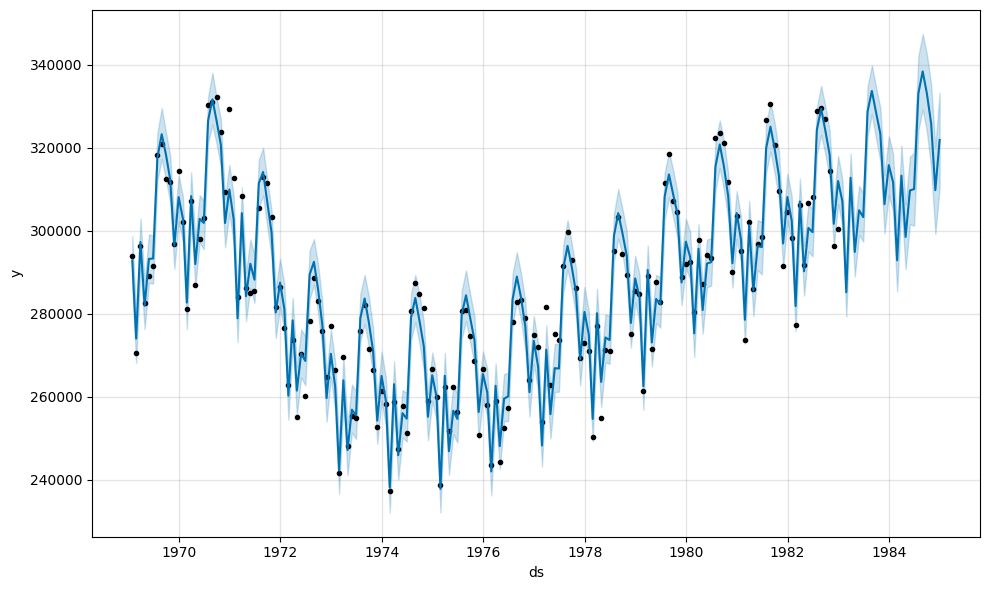

In [40]:
prophet_model.plot(forecast);

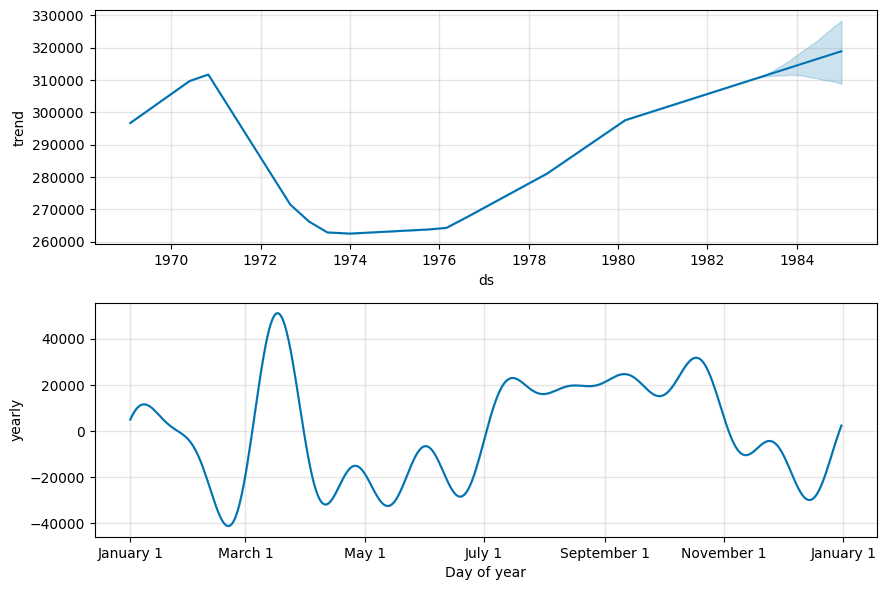

In [41]:
prophet_model.plot_components(forecast);

In [42]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [43]:
all_df = pd.concat([
    df_train_prophet,
    df_test_prophet
]).merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-24:],
    on='ds', how='left'
)

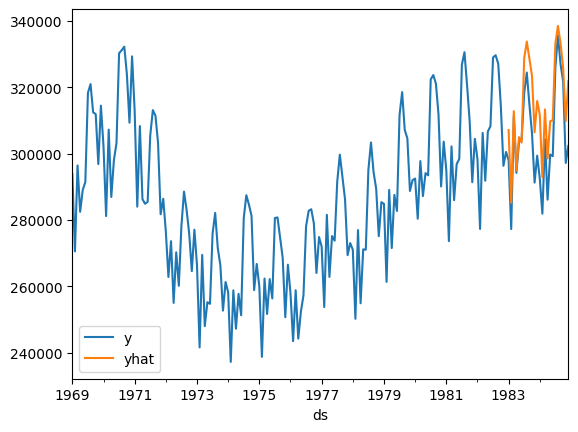

In [44]:
all_df.set_index('ds')[['y', 'yhat']].plot(); #.iloc[-offset:-offset+period].plot();

In [45]:
# Plotting the model results:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.index,
                         y=df_train.values ,
                         line=dict(color="royalblue", width=3),
                         name="Train Births"
                         ))
fig.add_trace(go.Scatter(x=df_test.index,
                         y=df_test.values,
                         line=dict(color="crimson", width=3),
                         name="Test Births",
                         mode="lines"))
fig.add_trace(go.Scatter(x=arima_preds.index,
                         y=arima_preds.values,
                         line=dict(color="darkviolet", width=3, dash='dot'),
                         name="AutoArima",
                         mode="lines")
                      )
fig.add_trace(go.Scatter(x=forecast.ds[-24:],
                         y=forecast.yhat[-24:],
                         line=dict(color="darkgreen", width=3),
                         name="Prophet",
                         mode="lines")
                      )

fig.update_layout(**layout_config_2,
    width=1200,
    height=600
)

fig.show()

## A model on daily data with Prophet

In [46]:
# Create a datetime from the year, month, day
# In the data every month has 31 days, with the value for day 31 = day 30
# So use errors='coerce', this will give NAs for those non-existent dates
births['date'] = pd.to_datetime(births[['year', 'month', 'day']], errors='coerce')
births = births.dropna()
births = births.set_index('date')
births_f = births.loc[births['gender'] == 'F', ['births']]

In [47]:
df_train = births_f.loc['1970':'1978'].reset_index()
df_train.columns = ['ds', 'y']
df_train

,ds,y
0,1970-01-01,4064
1,1970-01-02,4536
2,1970-01-03,4398
3,1970-01-04,3968
4,1970-01-05,4718
...,...,...
3282,1978-12-27,4904
3283,1978-12-28,4979
3284,1978-12-29,5097
3285,1978-12-30,4168


In [48]:
df_test = births_f.loc['1979':'1979'].reset_index()
df_test.columns = ['ds', 'y']
df_test

,ds,y
0,1979-01-01,4016
1,1979-01-02,4245
2,1979-01-03,4522
3,1979-01-04,4612
4,1979-01-05,4689
...,...,...
360,1979-12-27,5101
361,1979-12-28,5356
362,1979-12-29,4502
363,1979-12-30,4009


In [49]:
from prophet import Prophet

prophet_model = Prophet()
prophet_model.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/vg24h20x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/vvhbtbug.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99243', 'data', 'file=/tmp/tmpcm890knm/vg24h20x.json', 'init=/tmp/tmpcm890knm/vvhbtbug.json', 'output', 'file=/tmp/tmpcm890knm/prophet_modeluskr34dq/prophet_model-20251023080502.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
08:05:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:05:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [50]:
future = prophet_model.make_future_dataframe(periods=365, freq='D')
future

,ds
0,1970-01-01
1,1970-01-02
2,1970-01-03
3,1970-01-04
4,1970-01-05
...,...
3647,1979-12-27
3648,1979-12-28
3649,1979-12-29
3650,1979-12-30


In [51]:
forecast = prophet_model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1970-01-01,4843.152600,4595.006183,4999.594986,4843.152600,4843.152600,-41.605184,-41.605184,-41.605184,119.519005,119.519005,119.519005,-161.124189,-161.124189,-161.124189,0.0,0.0,0.0,4801.547416
1,1970-01-02,4843.897839,4687.088990,5077.695694,4843.897839,4843.897839,38.822301,38.822301,38.822301,202.811890,202.811890,202.811890,-163.989590,-163.989590,-163.989590,0.0,0.0,0.0,4882.720140
2,1970-01-03,4844.643078,4120.599130,4535.642058,4844.643078,4844.643078,-507.028076,-507.028076,-507.028076,-342.105660,-342.105660,-342.105660,-164.922416,-164.922416,-164.922416,0.0,0.0,0.0,4337.615002
3,1970-01-04,4845.388317,3916.345385,4314.666071,4845.388317,4845.388317,-732.547242,-732.547242,-732.547242,-568.595592,-568.595592,-568.595592,-163.951650,-163.951650,-163.951650,0.0,0.0,0.0,4112.841075
4,1970-01-05,4846.133556,4599.380520,4997.357531,4846.133556,4846.133556,-49.618318,-49.618318,-49.618318,111.532435,111.532435,111.532435,-161.150754,-161.150754,-161.150754,0.0,0.0,0.0,4796.515237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3647,1979-12-27,4499.320685,4242.847266,4768.071488,4348.647375,4646.992671,5.690133,5.690133,5.690133,119.519005,119.519005,119.519005,-113.828873,-113.828873,-113.828873,0.0,0.0,0.0,4505.010818
3648,1979-12-28,4499.388039,4316.783421,4841.654939,4348.075723,4647.835450,76.983488,76.983488,76.983488,202.811890,202.811890,202.811890,-125.828403,-125.828403,-125.828403,0.0,0.0,0.0,4576.371526
3649,1979-12-29,4499.455392,3754.938022,4274.795878,4347.504070,4648.416806,-478.636709,-478.636709,-478.636709,-342.105660,-342.105660,-342.105660,-136.531049,-136.531049,-136.531049,0.0,0.0,0.0,4020.818683
3650,1979-12-30,4499.522746,3515.071710,4072.348287,4346.660668,4648.948187,-714.324663,-714.324663,-714.324663,-568.595592,-568.595592,-568.595592,-145.729071,-145.729071,-145.729071,0.0,0.0,0.0,3785.198083


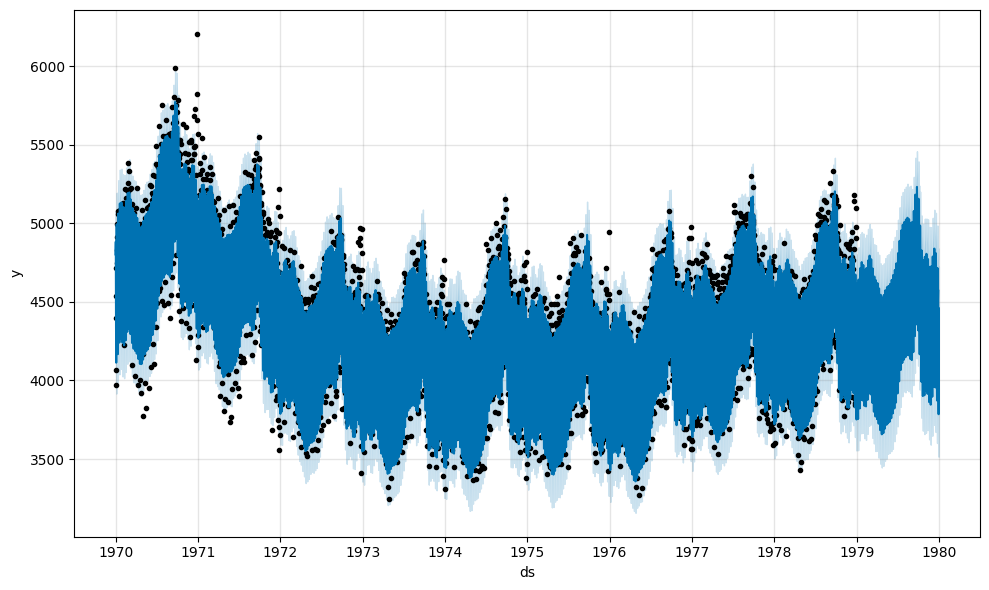

In [52]:
prophet_model.plot(forecast);

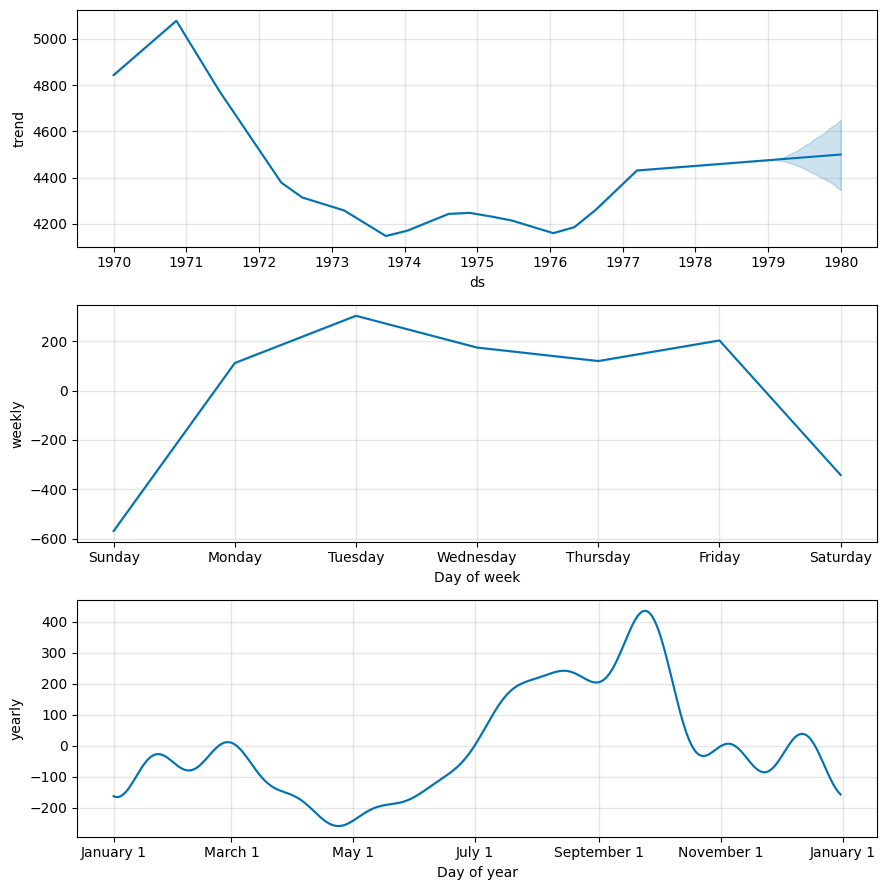

In [53]:
prophet_model.plot_components(forecast);

### In the cells below we run some code to be able to evaluate the model. Don't worry about the code, just skip to the next heading.

In [54]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(prophet_model, initial='730 days', period='91 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 25 forecasts with cutoffs between 1972-01-08 00:00:00 and 1977-12-31 00:00:00


  0%|          | 0/25 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/swkh37ul.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/acihbb6_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17036', 'data', 'file=/tmp/tmpcm890knm/swkh37ul.json', 'init=/tmp/tmpcm890knm/acihbb6_.json', 'output', 'file=/tmp/tmpcm890knm/prophet_model9i8psr2s/prophet_model-20251023080723.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
08:07:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:07:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/zwwxcdvc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcm890knm/eo1lghum.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1972-01-09,3761.410107,3534.422468,3971.310315,3852,1972-01-08
1,1972-01-10,4504.509358,4302.592398,4732.905602,4572,1972-01-08
2,1972-01-11,4743.538587,4522.438675,4956.620873,4855,1972-01-08
3,1972-01-12,4581.401253,4369.280374,4799.845887,4598,1972-01-08
4,1972-01-13,4486.957721,4262.407962,4718.423419,4628,1972-01-08


In [55]:
df_cv[df_cv.ds == "1976-08-31"]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
5806,1976-08-31,4693.792349,4450.775162,4944.362483,4639,1975-10-04
6080,1976-08-31,4618.282265,4373.917368,4831.014220,4639,1976-01-03
6354,1976-08-31,4622.551751,4406.578385,4842.682310,4639,1976-04-03
6628,1976-08-31,4662.417065,4463.419300,4862.682307,4639,1976-07-03


In [56]:
from prophet.diagnostics import performance_metrics

df_p = performance_metrics(df_cv, rolling_window=0.10)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,22576.265008,150.254002,118.408870,0.027968,0.023465,0.028051,0.838333
1,38 days,21930.072205,148.088056,118.222241,0.027800,0.023591,0.027905,0.838421
2,39 days,21185.906473,145.553792,117.496592,0.027599,0.023455,0.027735,0.840044
3,40 days,21279.308007,145.874288,117.836883,0.027684,0.023518,0.027837,0.837807
4,41 days,21129.877042,145.361195,117.793358,0.027683,0.023899,0.027833,0.837281
...,...,...,...,...,...,...,...,...
324,361 days,102833.341208,320.676381,262.603125,0.060974,0.053734,0.061768,0.552895
325,362 days,104925.969365,323.922783,265.116643,0.061590,0.053734,0.062399,0.550702
326,363 days,104602.466091,323.423045,264.439200,0.061395,0.053939,0.062223,0.552412
327,364 days,104069.906377,322.598677,263.647447,0.061355,0.053939,0.062213,0.557237


### Now let's look at how good our model behaves for forecasts in the future.

In the chart we see the MAPE for longer and longer horizons. We see that it increases for forecasts further in the future. That's no surprise.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



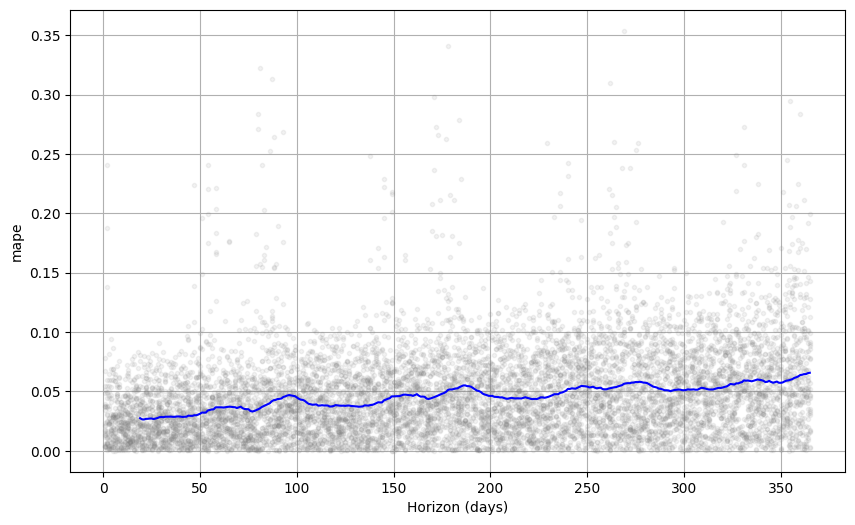

In [57]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='mape', rolling_window=0.05)

In [ ]:
df_train

In [ ]:
forecast.columns

In [58]:
all_df = pd.concat([
    df_train,
    df_test
]).merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-365:],
    on='ds', how='left'
)

In [59]:
all_df

,ds,y,yhat,yhat_lower,yhat_upper
0,1970-01-01,4064,NaN,NaN,NaN
1,1970-01-02,4536,NaN,NaN,NaN
2,1970-01-03,4398,NaN,NaN,NaN
3,1970-01-04,3968,NaN,NaN,NaN
4,1970-01-05,4718,NaN,NaN,NaN
...,...,...,...,...,...
3647,1979-12-27,5101,4505.010818,4242.847266,4768.071488
3648,1979-12-28,5356,4576.371526,4316.783421,4841.654939
3649,1979-12-29,4502,4020.818683,3754.938022,4274.795878
3650,1979-12-30,4009,3785.198083,3515.071710,4072.348287


### Let's compare forecast with real data for the first two months in the future


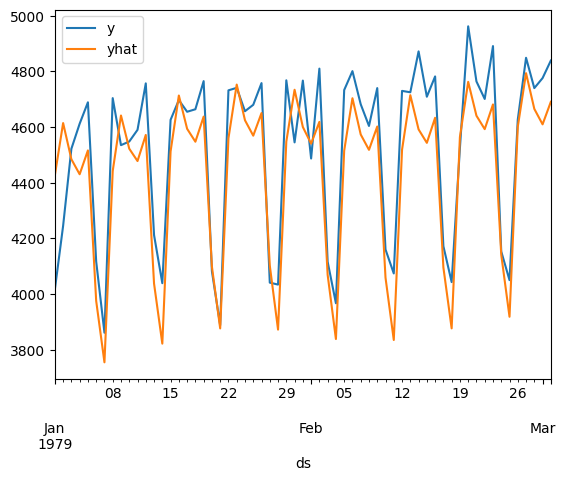

In [64]:
offset = 365
period = 61
all_df.set_index('ds')[['y', 'yhat']].iloc[-offset:-offset+period].plot();

### Let's compare forecast with real data for 11 and 12 months in the future

As you can see the difference starts to grow


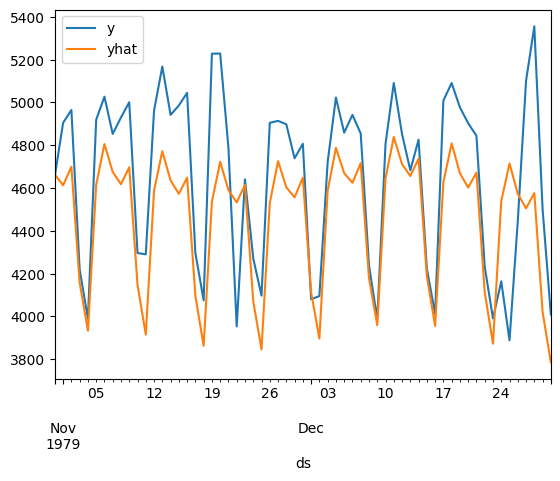

In [62]:
offset = 62
period = 61
all_df.set_index('ds')[['y', 'yhat']].iloc[-offset:-offset+period].plot();